<a href="https://colab.research.google.com/github/Kal-Aster/RNN_working_memory/blob/main/RNN_working_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [3]:
# Set some properties of the model. We'll store these in a dict so they're
# easier to pass around or save.
model = {}

# properties of the recurrent pool:
model['N'] = 1000  # number of neurons
model['g'] = 0.95  # gain of synaptic weights in pool
model['sp'] = 0.25  # fraction of weights that are nonzero
model['tau'] = 20  # neural membrane time constant in ms
model['dt'] = 0.1  # simulation timestep in ms
model['nonlin'] = lambda x: np.tanh(x)  # firing rate nonlinearity for pool units

# properties of the input layer:
# a note: we're going to encode the "value" of the input by the identity of the
# active input layer units. We'll use one-hot encoding: for each input step
# during simulation, one unit will be activated with "firing rate" 1, and the
# rest will be set to firing rate 0 (adjust gIn to change the scaling of input
# to the recurrent pool.)
# Note 1: This is just one way of setting up input- are there other approaches
# that would improve memory capacity?
# Note 2: Burn-in time is especially important if your model has g>1, in which
# case neurons will be spontaneously active.
model['nIn'] = 20  # size of the input layer
model['gIn'] = 10.0  # gain of the input weights
model['spIn'] = 0.05  # sparsity of input->pool connectivity
model['burnIn'] = 10  # time before input starts
model['durIn'] = 1  # time for which an input is active in ms
model['ISI'] = 0  # time between inputs in ms
model['nonlinIn'] = lambda x: x  # best to keep the input linear

In [4]:
# Create the synaptic weight matrix.
# Normalizing weights by sqrt(N*sparsity) keeps the eigenvalue spectrum
# invariant to the size of the population N.
randMat  = np.random.normal(0, 1, size=(model['N'], model['N']))
spMat  = np.random.uniform(0, 1, size=(model['N'], model['N'])) <= model['sp']
model['J'] = np.multiply(randMat, spMat) * model['g'] / math.sqrt(model['N'] * model['sp'])

# Create the input weight matrix.
randMatIn = np.random.normal(0, 1, size=(model['N'], model['nIn']))
spMatIn = np.random.uniform(0, 1, size=(model['N'], model['nIn'])) <= model['spIn']
model['Jin'] = np.multiply(randMatIn, spMatIn) * model['gIn'] / math.sqrt(model['nIn'] * model['spIn'])

In [5]:
# Define a couple helper functions for simulation.

def step(firing_rates, input_layer, model):
  # The simulation function. We use Euler's method to simulate the evolution of
  # model neuron firing rates given the input_layer firing rates.

  timestep = math.exp(-model['dt']/model['tau'])
  vIn = np.matmul(model['J'], firing_rates) \
        + np.matmul(model['Jin'], model['nonlinIn'](input_layer))
  updated_rates = model['nonlin'](vIn + (firing_rates - vIn) * timestep)

  return updated_rates


def make_input(sequence_length, model):
  # Generates a sequence of inputs according to the parameters in model. Returns
  # the sequence both as a one-hot encoding and as a sequence of integer values.

  input_stream = [0] * int(model['burnIn']/model['dt'])

  for i in range(sequence_length):
    val = np.random.randint(0, model['nIn']) + 1
    for t in range(int(model['ISI']/model['dt'])):
      input_stream.append(0.0)
    for t in range(int(model['durIn']/model['dt'])):
      input_stream.append(val)

  input_stream = np.array(input_stream)

  onehot = np.zeros((model['nIn'] + 1, input_stream.size))
  onehot[input_stream, np.arange(input_stream.size)] = 1.0
  onehot = onehot[1:, :]

  return onehot, input_stream

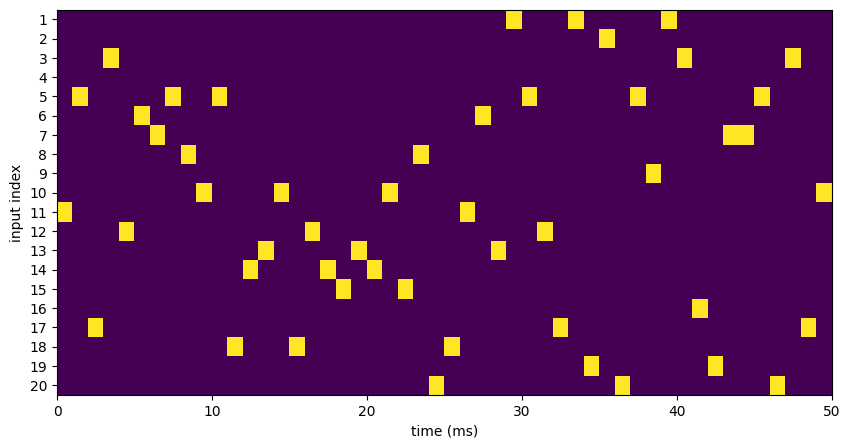

In [6]:
# Look at an example input stream.

onehot, stream = make_input(50, model)

omit = int(model['burnIn']/model['dt']) # don't plot the burn-in period
onehot_plot = onehot[:, omit:]

fig, ax = plt.subplots(figsize=(10, 5))
# extent maps row k (0-indexed) to the range [k+0.5, k+1.5], so integer
# ticks at 1..nIn land exactly on the center of each row's cell.
extent = [0, onehot_plot.shape[1] * model['dt'], model['nIn'] + 0.5, 0.5]
ax.imshow(onehot_plot, aspect='auto', interpolation='nearest', extent=extent)
ax.set_yticks(np.arange(1, model['nIn'] + 1))
ax.set_xlabel('time (ms)')
ax.set_ylabel('input index')
fig.show()

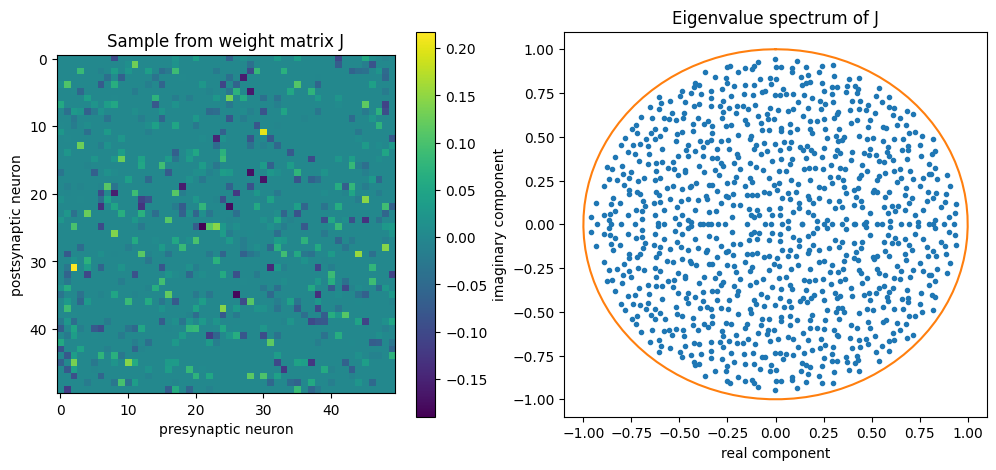

In [7]:
# Take a look at the eigenvalue spectrum of J.
w, v = np.linalg.eig(model['J'])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
showCount = 50  # portion of J to actually show (for readability)
h = ax[0].imshow(model['J'][:showCount,:showCount])
ax[0].set_title('Sample from weight matrix J')
ax[0].set_xlabel('presynaptic neuron')
ax[0].set_ylabel('postsynaptic neuron')
plt.colorbar(h, ax=ax[0])

ax[1].plot(np.real(w),np.imag(w),'.')
ax[1].plot(np.sin(np.linspace(0,2*math.pi,100)),
           np.cos(np.linspace(0,2*math.pi,100)))  # circle with radius 1
ax[1].set_title('Eigenvalue spectrum of J')
ax[1].set_xlabel('real component')
ax[1].set_ylabel('imaginary component')
fig.show()

In [8]:
# Simulate the model activity.

# generate the input to the model
onehot, input_stream = make_input(200, model)

# initialize the firing rates randomly
firing_rates = np.zeros((model['N'], len(input_stream)))
firing_rates[:, 0] = np.random.uniform(0, 0.1, size=(model['N']))

for t in range(len(input_stream)-1):
  firing_rates[:,t+1] = step(firing_rates[:,t], onehot[:,t], model)

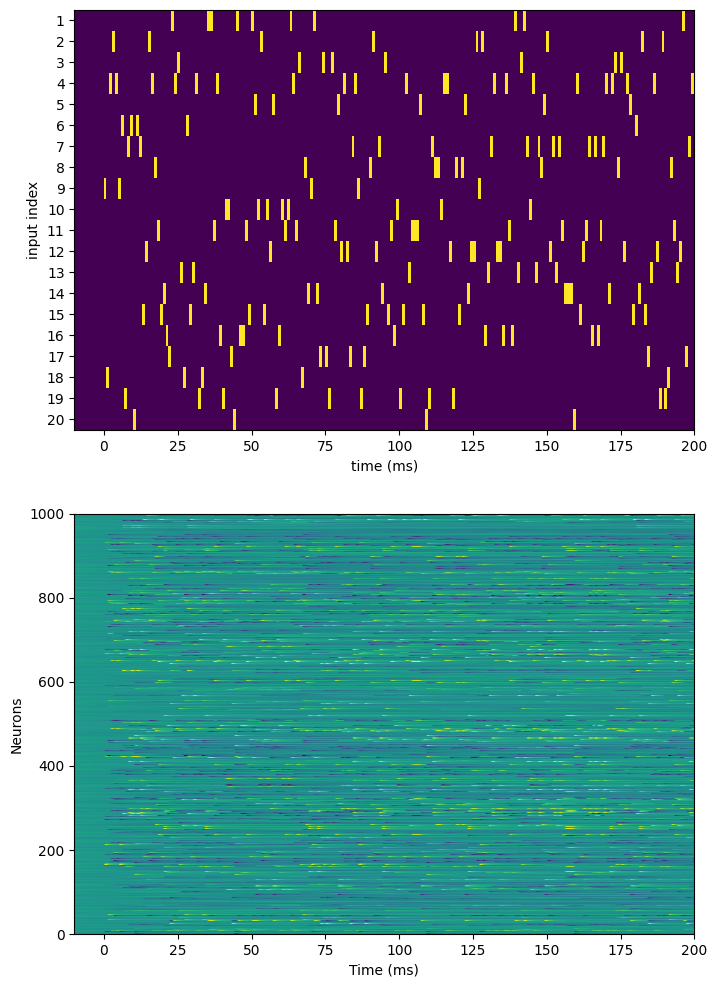

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(8, 12))
# extent maps row k (0-indexed) to the range [k+0.5, k+1.5], so integer
# ticks at 1..nIn land exactly on the center of each row's cell.
extent = [-model['burnIn'], onehot.shape[1] * model['dt'] - model['burnIn'], model['nIn'] + 0.5, 0.5]
ax[0].imshow(onehot, aspect='auto', interpolation='nearest', extent=extent)
ax[0].set_yticks(np.arange(1, model['nIn'] + 1))
ax[0].set_xlabel('time (ms)')
ax[0].set_ylabel('input index')
fig.show()

extents = [-model['burnIn'], onehot.shape[1] * model['dt'] - model['burnIn'], 0, model['N']]
ax[1].imshow(firing_rates, aspect='auto', interpolation='nearest', extent=extents)
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('Neurons')
fig.show()

In [63]:
def get_last_firing_rates_from_timestep(firing_rates, timestep, interval):
  return np.vstack([firing_rates[:, (timestep - i):-i] if i > 0 else firing_rates[:, (timestep - i):] for i in range(interval + 1)])

In [89]:
def create_model(firing_rates, input_stream, burnInData, k, fr_interval):
  if k < 0:
    raise ValueError('k must be greater than or equal to 0')

  if fr_interval > k:
    raise ValueError('fr_interval must be less than or equal to k')

  print(f"{firing_rates.shape=}")
  X = get_last_firing_rates_from_timestep(firing_rates, burnInData + k, fr_interval).T
  y = input_stream[burnInData:-k] if k > 0 else input_stream[burnInData:]
  print(f"{X.shape=}, {y.shape=}")

  best_accuracy = None
  best_model = None
  for C in [.25, .5, .75, 1]:
    print(f"Trying model with {C=}")

    model = LogisticRegression(penalty="l2", solver="saga", C=C, max_iter=5000)

    accs = cross_val_score(model, X, y, cv=2)
    this_accuracy = accs.mean()
    print(f"Accuracy: {this_accuracy:.4%}")

    # Store the average test accuracy for this value of C
    if best_accuracy is None or best_accuracy < this_accuracy:
      print("New best accuracy found!")
      best_accuracy = this_accuracy
      best_model = model

  if best_model is None:
    raise RuntimeError('Cannot find best model')

  print(f"Best accuracy: {best_accuracy:.4%}")

  best_model.fit(X, y)

  return best_model

In [90]:
burnInData = int(model['burnIn']/model['dt'])

def test(ks):
  for k in ks:
    print(f"Creating model for {k=}")
    fr_interval = 5
    model = create_model(firing_rates, input_stream, burnInData, k, fr_interval)
    print("----\nModel created:")
    print(model)
    prediction = model.predict(get_last_firing_rates_from_timestep(firing_rates, burnInData + k, fr_interval).T)
    errors = 0
    for index, neuron in enumerate(input_stream[burnInData:-k]):
      if neuron == prediction[index]:
        continue
      # print(index, neuron, prediction[index])
      errors += 1
    print(f"{k=}, {errors=}")

test([20])

Creating model for k=20
firing_rates.shape=(1000, 2100)
X.shape=(1980, 6000), y.shape=(1980,)
Trying model with C=0.25
Accuracy: 17.5758%
New best accuracy found!
Trying model with C=0.5
Accuracy: 17.5758%
Trying model with C=0.75
Accuracy: 17.1212%
Trying model with C=1
Accuracy: 16.9192%
Best accuracy: 17.5758%
----
Model created:
LogisticRegression(C=0.25, max_iter=5000, solver='saga')
k=20, errors=306
